In [2]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import configparser
from ipywidgets import interact, IntSlider
from mpl_toolkits.mplot3d import Axes3D


In [10]:
train_dir = Path("./ACDC/database/training")
data = []

for patient_folder in sorted(train_dir.glob("patient*")):
    patient_id = patient_folder.name
    
    # Parse Info.cfg
    info_path = patient_folder / "Info.cfg"
    info = {}
    if info_path.exists():
        with open(info_path, 'r') as f:
            for line in f:
                if ':' in line:
                    key, value = line.split(':', 1)
                    key, value = key.strip(), value.strip()
                    if key in ['Height', 'Weight', 'NbFrame', 'ED', 'ES']:
                        info[key] = float(value) if '.' in value else int(value)
                    else:
                        info[key] = value
    
    # Dynamische ED/ES
    for frame_type, frame_key in [('ED', 'ED'), ('ES', 'ES')]:
        if frame_key in info:
            frame_num = info[frame_key]
            frame_str = f"frame{frame_num:02d}"
            
            img_paths = list(patient_folder.glob(f"*{frame_str}.nii.gz"))
            gt_paths = list(patient_folder.glob(f"*{frame_str}_gt.nii.gz"))
            
            if img_paths:
                img_path = img_paths[0]
                gt_path = gt_paths[0] if gt_paths else None
                
                # Image dimensies
                img = nib.load(img_path)
                data3d_img = img.get_fdata()
                H_img, W_img = data3d_img.shape[:2]
                S_img = data3d_img.shape[2] if len(data3d_img.shape) > 2 else 1
                
                # GT dimensies (nieuw!)
                if gt_path:
                    gt_img = nib.load(gt_path)
                    data3d_gt = gt_img.get_fdata()
                    H_gt, W_gt = data3d_gt.shape[:2]
                    S_gt = data3d_gt.shape[2] if len(data3d_gt.shape) > 2 else 1
                else:
                    H_gt = W_gt = S_gt = np.nan
                
                row = {
                    'patient': patient_id, 
                    'frame_type': frame_type,
                    **info,
                    'H_img': H_img, 'W_img': W_img, 'S_img': S_img,  # Image dims
                    'H_gt': H_gt, 'W_gt': W_gt, 'S_gt': S_gt,         # GT dims
                    'nii_file': img_path.name,
                    'gt_file': gt_path.name if gt_path else None
                }
                data.append(row)

df = pd.DataFrame(data)
print(f"✅ {len(df)} ED/ES geladen ({df['patient'].nunique()}/100 patients)")
print(df.head())

# H=height, W=width, S=slices

✅ 200 ED/ES geladen (100/100 patients)
      patient frame_type  ED  ES Group  Height  NbFrame  Weight  H_img  W_img  \
0  patient001         ED   1  12   DCM   184.0       30    95.0    216    256   
1  patient001         ES   1  12   DCM   184.0       30    95.0    216    256   
2  patient002         ED   1  12   DCM   160.0       30    70.0    232    256   
3  patient002         ES   1  12   DCM   160.0       30    70.0    232    256   
4  patient003         ED   1  15   DCM   165.0       30    77.0    256    256   

   S_img  H_gt  W_gt  S_gt                   nii_file  \
0     10   216   256    10  patient001_frame01.nii.gz   
1     10   216   256    10  patient001_frame12.nii.gz   
2     10   232   256    10  patient002_frame01.nii.gz   
3     10   232   256    10  patient002_frame12.nii.gz   
4     10   256   256    10  patient003_frame01.nii.gz   

                        gt_file  
0  patient001_frame01_gt.nii.gz  
1  patient001_frame12_gt.nii.gz  
2  patient002_frame01_gt.nii.

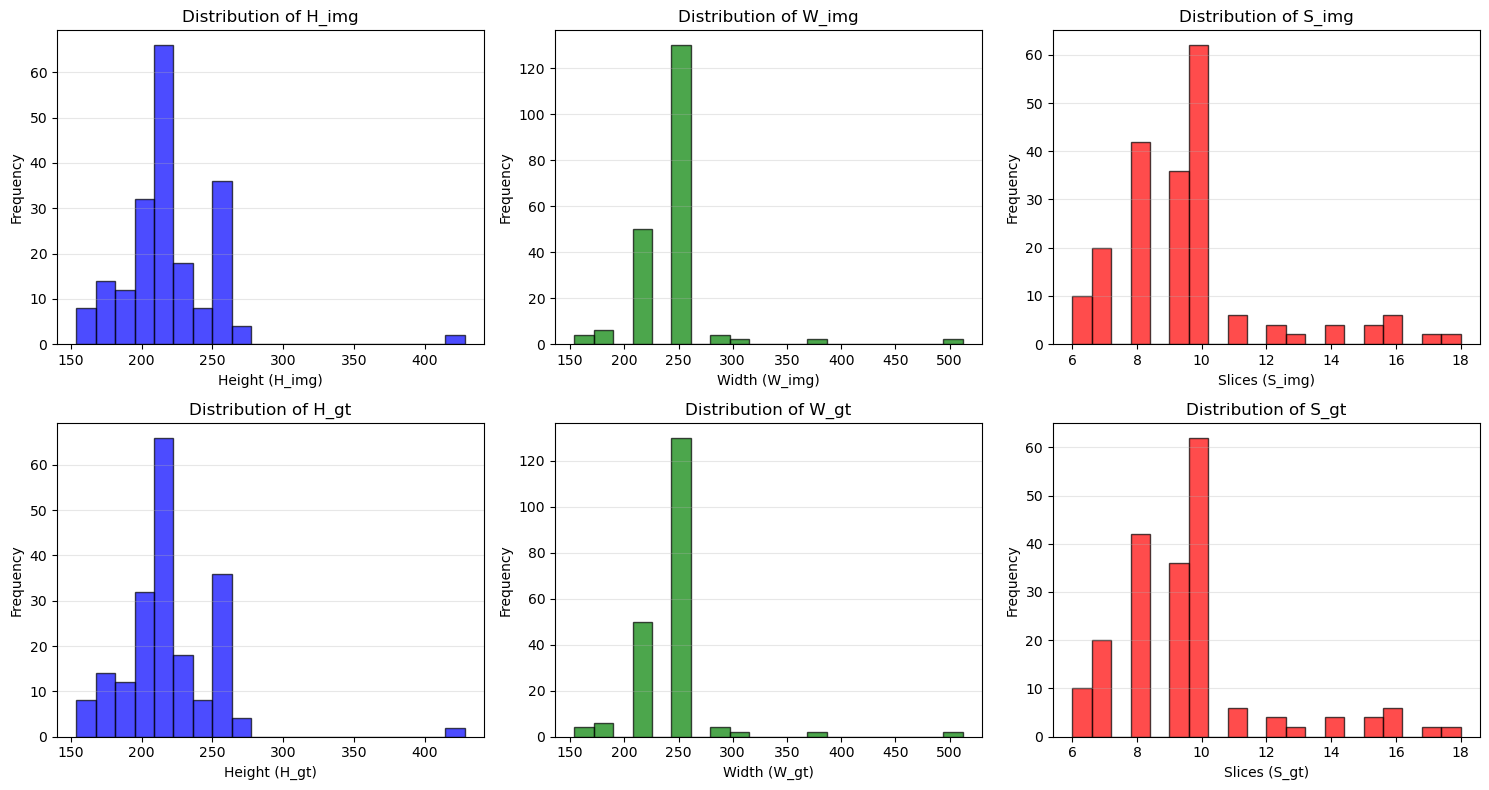

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 0 - Image (img)
axes[0, 0].hist(df['H_img'], bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_xlabel('Height (H_img)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of H_img')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].hist(df['W_img'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Width (W_img)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of W_img')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[0, 2].hist(df['S_img'], bins=20, edgecolor='black', alpha=0.7, color='red')
axes[0, 2].set_xlabel('Slices (S_img)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of S_img')
axes[0, 2].grid(axis='y', alpha=0.3)

# Row 1 - GT (Ground Truth)
axes[1, 0].hist(df['H_gt'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[1, 0].set_xlabel('Height (H_gt)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of H_gt')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].hist(df['W_gt'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Width (W_gt)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of W_gt')
axes[1, 1].grid(axis='y', alpha=0.3)

axes[1, 2].hist(df['S_gt'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='red')
axes[1, 2].set_xlabel('Slices (S_gt)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of S_gt')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
# NIfTI Header inspection
patient_folder = Path("./ACDC/database/training") / df.iloc[0]['patient']
img_path = patient_folder / df.iloc[0]['nii_file']

img = nib.load(img_path)
header = img.header

print(f"File: {img_path.name}")
print("\n=== NIfTI HEADER ===")
print(header)


File: patient001_frame01.nii.gz

=== NIfTI HEADER ===
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  3 216 256  10   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [ 1.      1.5625  1.5625 10.      1.      1.      1.      1.    ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 

In [5]:
# NIfTI Header inspection - 4D file
img_path_4d = Path("./ACDC/database/training/patient001/patient001_4d.nii.gz")

img_4d = nib.load(img_path_4d)
header_4d = img_4d.header

print(f"File: {img_path_4d.name}")
print("\n=== NIfTI HEADER (4D) ===")
print(header_4d)


File: patient001_4d.nii.gz

=== NIfTI HEADER (4D) ===
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 16384
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  4 216 256  10  30   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [ 1.      1.5625  1.5625 10.      1.      1.      1.      1.    ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 614.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 1071
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : unknown
sform_code      : unknown
quatern_b       : 0.0
quatern_

In [6]:
# Group distribution per unique patient
group_names = {
    'NOR': 'Normal',
    'MINF': 'myocardial infarction',
    'DCM': 'dilated cardiomyopathy',
    'HCM': 'hypertrophic cardiomyopathy',
    'RV': 'abnormal right ventricle'
}

patients_per_group = df.groupby('Group')['patient'].nunique().sort_index()
print("=== PATIENTS PER GROUP ===")
for group in sorted(patients_per_group.index):
    count = patients_per_group[group]
    description = group_names.get(group, group)
    print(f"{group:5} {int(count):3d}  ({description})")


=== PATIENTS PER GROUP ===
DCM    21  (dilated cardiomyopathy)
HCM    20  (hypertrophic cardiomyopathy)
MINF   20  (myocardial infarction)
NOR    20  (Normal)
RV     20  (abnormal right ventricle)


In [13]:
data_4d_files = []

for patient_folder in sorted(train_dir.glob("patient*")):
    patient_id = patient_folder.name
    
    four_d_files = list(patient_folder.glob("*_4d.nii.gz"))
    
    for file_path in four_d_files:
        row = {
            'patient': patient_id,
            'file_name': file_path.name
        }
        data_4d_files.append(row)

df_4d_files = pd.DataFrame(data_4d_files)
print(f"{len(df_4d_files)} 4D images found ({df_4d_files['patient'].nunique()} patients)")
print(df_4d_files.head())

100 4D images found (100 patients)
      patient             file_name
0  patient001  patient001_4d.nii.gz
1  patient002  patient002_4d.nii.gz
2  patient003  patient003_4d.nii.gz
3  patient004  patient004_4d.nii.gz
4  patient005  patient005_4d.nii.gz


In [22]:
data_4d_pixdim = []

for _, row in df_4d_files.iterrows():
    patient_id = row['patient']
    file_name = row['file_name']
    img_path_4d = train_dir / patient_id / file_name
    
    if img_path_4d.exists():
        img_4d = nib.load(img_path_4d)
        header_4d = img_4d.header
        pixdim_4d = header_4d.get_zooms()
        
        data_4d_pixdim.append({
            'patient': patient_id,
            'pixdim_x': pixdim_4d[0],
            'pixdim_y': pixdim_4d[1]
        })

df_4d_pixdim = pd.DataFrame(data_4d_pixdim)
df_4d_pixdim

,patient,pixdim_x,pixdim_y
0,patient001,1.562500,1.562500
1,patient002,1.367188,1.367188
2,patient003,1.562500,1.562500
3,patient004,1.367188,1.367188
4,patient005,1.406250,1.406250
...,...,...,...
95,patient096,1.682690,1.682690
96,patient097,1.484380,1.484380
97,patient098,1.250000,1.250000
98,patient099,1.785710,1.785710


Pixdim_x: mean=1.5117, std=0.1856, median=1.5625


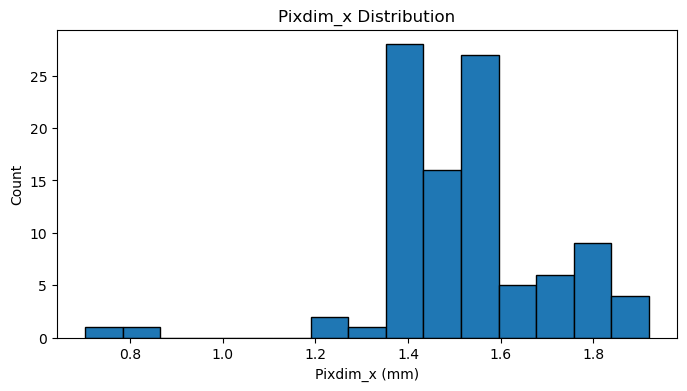

In [23]:
# Stats
mean_x = df_4d_pixdim['pixdim_x'].mean()
std_x = df_4d_pixdim['pixdim_x'].std()
median_x = df_4d_pixdim['pixdim_x'].median()

print(f"Pixdim_x: mean={mean_x:.4f}, std={std_x:.4f}, median={median_x:.4f}")

# Histogram
plt.figure(figsize=(8,4))
plt.hist(df_4d_pixdim['pixdim_x'], bins=15, edgecolor='black')
plt.xlabel('Pixdim_x (mm)')
plt.ylabel('Count')
plt.title('Pixdim_x Distribution')
plt.show()

In [26]:
## Pixdim_x frequency
df_4d_pixdim['pixdim_x'].value_counts().round(4).head(100)

pixdim_x
1.562500    27
1.367188    14
1.367190    10
1.484380     6
1.445310     5
1.785710     5
1.406250     4
1.875000     3
1.445312     3
1.682690     3
1.757812     2
1.757810     2
1.679690     2
1.640620     2
1.651790     2
1.679688     1
1.484375     1
0.833333     1
1.919640     1
0.703125     1
1.640625     1
1.215280     1
1.458330     1
1.250000     1
1.315790     1
Name: count, dtype: int64